# Week 7: CNN (Convolutional Neural Networks) 기초 (2026-05-12)

## 1. 실습 개요
- CNN의 주요 구성 요소(Conv, Pooling, Padding, Stride) 이해
- PyTorch를 이용한 CNN 모델 설계 및 이미지 분류 실습
- MNIST 데이터셋을 활용한 MLP vs CNN 성능 비교

In [24]:
import torch
import torch.nn as nn
from torch.optim import Adam
from torch.utils.data import DataLoader, TensorDataset
from torchvision import datasets, transforms
from torchvision.transforms import ToTensor
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder
import torchvision.transforms as transforms
from PIL import Image
import cv2
from torchsummary import summary

from config import CONTENT_DIR

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams['font.family'] = 'NanumGothic' # Windows
# plt.rcParams['font.family'] = 'AppleGothic' # Mac
plt.rcParams['axes.unicode_minus'] = False

# 시드 고정
def set_seed(seed=42):
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    np.random.seed(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

torch.set_printoptions(linewidth=1000)
set_seed(2026)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cpu


## 2. CNN 모델 구조 설계 (예시)

기본적인 CNN 구조는 다음과 같습니다:
1. **Convolution Layer**: 특징 추출
2. **Activation Function (ReLU)**: 비선형성 추가
3. **Pooling Layer**: 차원 축소 및 중요한 정보 강조
4. **Fully Connected Layer (Linear)**: 최종 분류

In [25]:
class SimpleCNN(nn.Module):
    # 생성 시점에 입력 채널 수와 클래스 개수를 받음
    def __init__(self, in_channels=1, n_classes=10): 
        super(SimpleCNN, self).__init__()
        self.conv_layer = nn.Sequential(
            nn.Conv2d(in_channels, 32, kernel_size=3, padding=1), # 주입받은 채널 사용
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )
        self.fc_layer = nn.Sequential(
            nn.Linear(64 * 7 * 7, 128),
            nn.ReLU(),
            nn.Linear(128, n_classes) # 주입받은 클래스 수 사용
        )

    def forward(self, x):
        x = self.conv_layer(x)
        x = x.view(x.size(0), -1) # Flatten
        x = self.fc_layer(x)
        return x

model = SimpleCNN().to(device)
print(model)

SimpleCNN(
  (conv_layer): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (fc_layer): Sequential(
    (0): Linear(in_features=3136, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=10, bias=True)
  )
)


In [26]:
def make_DataSet(x_train, x_val, y_train, y_val, batch_size=32):
    """pandas/numpy 데이터를 PyTorch 학습용 DataLoader와 검증 텐서로 변환합니다."""

    # 데이터 텐서로 변환
    x_train_tensor = torch.tensor(np.array(x_train), dtype=torch.float32)
    y_train_tensor = torch.tensor(np.array(y_train), dtype=torch.long)
    x_val_tensor = torch.tensor(np.array(x_val), dtype=torch.float32)
    y_val_tensor = torch.tensor(np.array(y_val), dtype=torch.long)

    # TensorDataset 생성 : 텐서 데이터셋으로 합치기
    train_dataset = TensorDataset(x_train_tensor, y_train_tensor)

    # DataLoader 생성
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

    return train_loader, x_val_tensor, y_val_tensor

def train(dataloader, model, loss_fn, optimizer, device):
    """한 epoch 동안 모델을 학습하고 평균 train loss를 반환합니다."""
    model.train()                               # 훈련 모드로 설정
    total_loss = 0

    for x, y in dataloader:                # (x, y) : 입력 데이터와 레이블
        x, y = x.to(device), y.to(device)  # 입력 데이터와 레이블을 지정된 장치(device, CPU 또는 GPU)로 이동

        # Feed Forward
        optimizer.zero_grad()              # 이전 배치의 gradient를 초기화
        pred = model(x)
        loss = loss_fn(pred, y)

        # Backpropagation
        loss.backward()                    # 역전파를 통해 모델의 각 파라미터에 대한 손실의 기울기를 계산
        optimizer.step()                   # 옵티마이저가 계산된 기울기를 사용하여 모델의 파라미터를 업데이트

        total_loss += loss.item() * x.size(0)  # 배치 평균 loss에 배치 크기를 곱해 배치 전체 loss로 누적

    return total_loss / len(dataloader.dataset)  # 전체 데이터 개수로 나누어 epoch 평균 loss 반환    

def evaluate(x_val_tensor, y_val_tensor, model, loss_fn, device):
    """검증/테스트 데이터 전체에 대한 loss와 예측값을 반환합니다."""

    model.eval()  # 모델을 평가 모드로 설정

    with torch.no_grad():  # 평가 과정에서는 기울기를 계산하지 않음
        x = x_val_tensor.to(device)
        y = y_val_tensor.to(device)
        pred = model(x)
        eval_loss = loss_fn(pred, y).item()

    return eval_loss, pred

def dl_learning_curve(tr_loss_list, val_loss_list):
    epochs = range(1, len(tr_loss_list) + 1)

    plt.figure(figsize=(7, 4))
    plt.plot(epochs, tr_loss_list, label="train_loss", marker=".")
    plt.plot(epochs, val_loss_list, label="val_loss", marker=".")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()

In [27]:
# Download training data from open datasets.
train_dataset = datasets.MNIST(
    root="data",
    train=True,
    download=True,
    transform=ToTensor(),  # 픽셀값을 [0, 1] 사이로 정규화하고 텐서로 변환
)

# Download test data from open datasets.
test_dataset = datasets.MNIST(
    root="data",
    train=False,
    download=True,
    transform=ToTensor(),
)

Epoch 1, train loss : 0.196037, val loss : 0.073226
Epoch 2, train loss : 0.055531, val loss : 0.049834
Epoch 3, train loss : 0.039729, val loss : 0.049397
Epoch 4, train loss : 0.029932, val loss : 0.046903
Epoch 5, train loss : 0.024397, val loss : 0.037426
Epoch 6, train loss : 0.019345, val loss : 0.044045
Epoch 7, train loss : 0.015661, val loss : 0.039429
Epoch 8, train loss : 0.012353, val loss : 0.045612
Epoch 9, train loss : 0.010356, val loss : 0.049370
Epoch 10, train loss : 0.008249, val loss : 0.067559


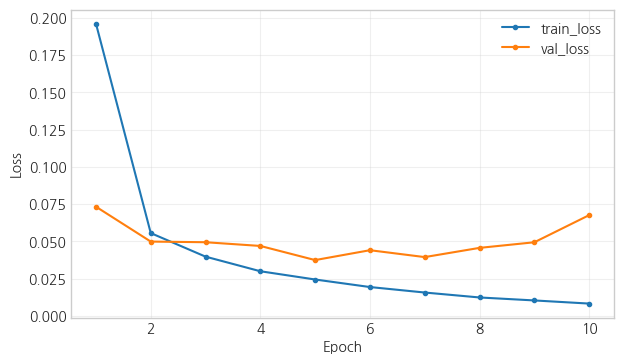

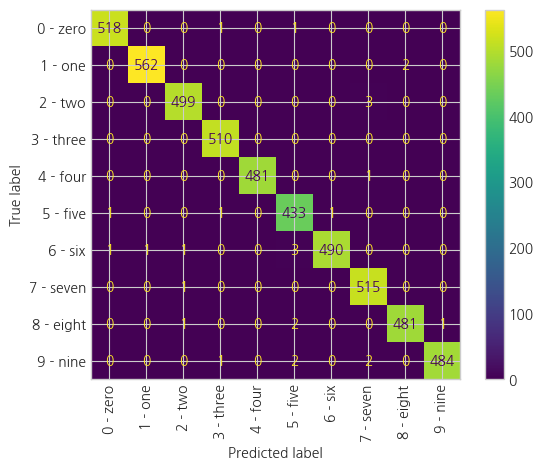

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       520
           1       1.00      1.00      1.00       564
           2       0.99      0.99      0.99       502
           3       0.99      1.00      1.00       510
           4       1.00      1.00      1.00       482
           5       0.98      0.99      0.99       436
           6       1.00      0.99      0.99       496
           7       0.99      1.00      0.99       516
           8       1.00      0.99      0.99       485
           9       1.00      0.99      0.99       489

    accuracy                           0.99      5000
   macro avg       0.99      0.99      0.99      5000
weighted avg       0.99      0.99      0.99      5000



In [29]:
batch_size = 64
train_dataloader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

X_val, X_test = test_dataset.data[:5000], test_dataset.data[5000:]
y_val, y_test = test_dataset.targets[:5000], test_dataset.targets[5000:]

# 모든 픽셀값 [0,1] 범위로 변환
X_val = X_val / 255
X_test = X_test / 255

X_val = X_val.view(5000, 1, 28, 28)     # [1 * 28 * 28 이미지 5000장] 구조로 변환
X_test = X_test.view(5000, 1, 28, 28)

n_class = 10

# 모델 구조 설계
model1 = nn.Sequential(
    nn.Conv2d(1,32, kernel_size=3, padding=1),
    nn.ReLU(),
    nn.MaxPool2d(kernel_size=2, stride=2, padding=0),
    nn.Conv2d(32,64, kernel_size=3, padding=1),
    nn.ReLU(),
    nn.MaxPool2d(kernel_size=2, stride=2, padding=0),
    nn.Flatten(),
    nn.Linear(64*7*7, 64),
    nn.ReLU(),
    nn.Linear(64, n_class)
).to(device)

loss_fn = nn.CrossEntropyLoss()
optimizer = Adam(model1.parameters(), lr=0.001)

epochs = 10
tr_loss_list, val_loss_list = [], []

for t in range(epochs):
    tr_loss = train(train_dataloader, model1, loss_fn, optimizer, device)
    val_loss, _ = evaluate(X_val, y_val, model1, loss_fn, device)

    # 리스트에 loss 추가 --> learning curve 그리기 위해.
    tr_loss_list.append(tr_loss)
    val_loss_list.append(val_loss)

    print(f"Epoch {t+1}, train loss : {tr_loss:4f}, val loss : {val_loss:4f}")

dl_learning_curve(tr_loss_list, val_loss_list)

_, pred = evaluate(X_test, y_test, model1, loss_fn, device)
pred_prob = nn.functional.softmax(pred, dim=1)
pred_class = np.argmax(pred_prob.cpu().numpy(), axis=1)
cm = confusion_matrix(y_test.numpy(), pred_class)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=train_dataset.classes)
disp.plot()
plt.xticks(rotation=90)
plt.show()
print(classification_report(y_test.numpy(), pred_class))

torch.Size([27, 28, 28])


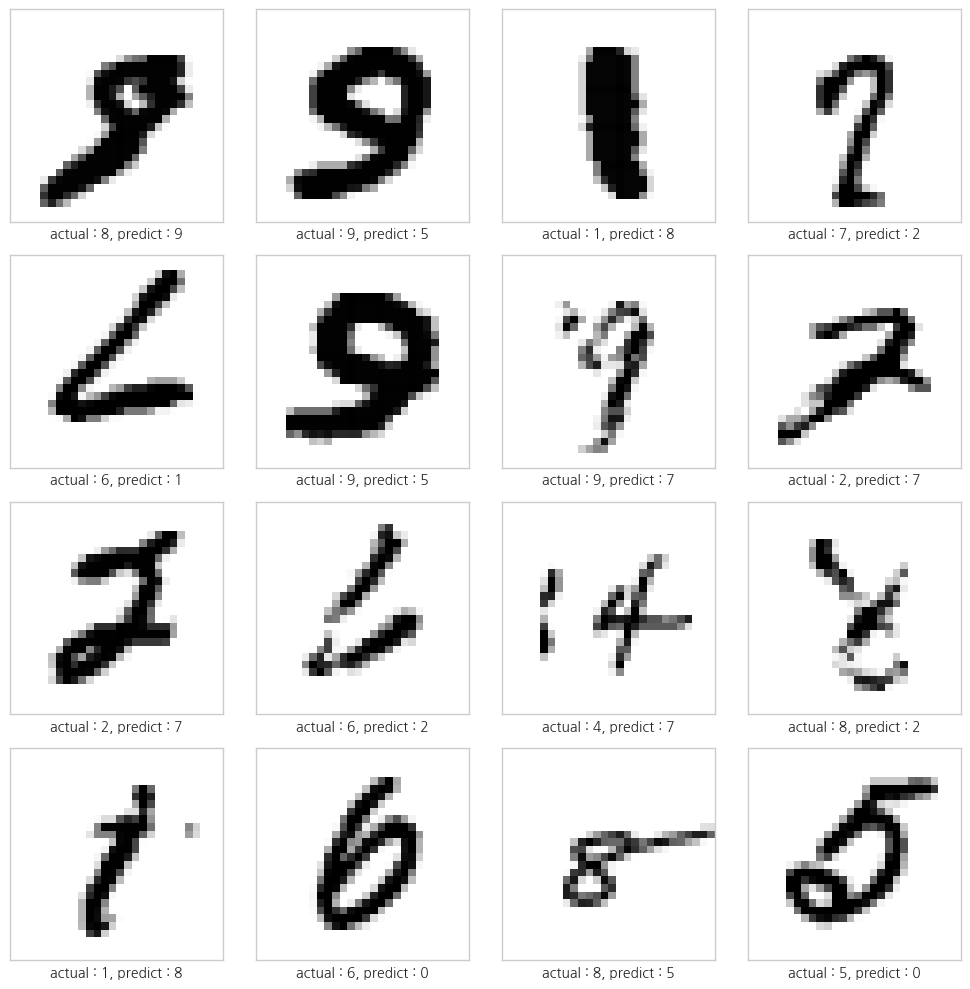

In [ ]:
import random as rd
idx = (y_test.numpy() != pred_class)
X_test_wr = X_test[idx]
y_test_wr = y_test[idx]
pred_wr = pred_class[idx]

X_test_wr = X_test_wr.reshape(-1, 28, 28)

idx = rd.sample(range(X_test_wr.shape[0]), min(16, X_test_wr.shape[0]))
X_temp = X_test_wr[idx]
y_temp = y_test_wr[idx]
p_temp = pred_wr[idx]

plt.figure(figsize=(10, 10))
for i in range(len(idx)):
    plt.subplot(4, 4, i + 1)
    plt.xticks([])
    plt.yticks([])
    plt.imshow(X_temp[i], cmap=plt.cm.binary)
    plt.xlabel(f"actual : {y_temp[i]}, predict : {p_temp[i]}")
plt.tight_layout()
plt.show()

입력데이터
(28, 28)
--------------------------------------------------


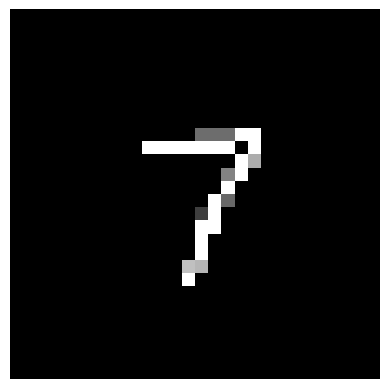

np.int64(7)

In [41]:
model1.eval()

image_path = f"{CONTENT_DIR}/7.png"

def predict_number(model, image_path, device):
    mage = Image.open(image_path).convert("L")
    img = np.array(mage)

    # 1. 색 반전 후 크기 조절하기
    img = cv2.resize(255 - img, (28, 28))

    print("입력데이터")
    print(img.shape)
    print("-" * 50)
    plt.imshow(img, cmap="gray")
    plt.axis("off")
    plt.show()

    # 2. (1, 1, 28, 28)로 변환
    new_data = img.reshape(1, 1, 28, 28)

    # 3. 스케일링
    new_data = new_data / 255

    # 4. 텐서로 변환
    new_data = torch.tensor(new_data, dtype=torch.float32)

    # 5. 예측
    model.eval()
    with torch.no_grad():
        new_data = new_data.to(device)
        pred = model(new_data)
        pred_prob = nn.functional.softmax(pred, dim=1)
        pred_class = np.argmax(pred_prob.cpu().numpy(), axis=1)

    return pred_class[0]

predict_number(model1, image_path, device)

In [42]:
train_dataset = datasets.FashionMNIST(root='data', train=True, download=True, transform=ToTensor())
test_dataset = datasets.FashionMNIST(root='data', train=False, download=True, transform=ToTensor())

Epoch 1, train loss : 0.497146, val loss : 0.371682
Epoch 2, train loss : 0.324366, val loss : 0.331361
Epoch 3, train loss : 0.277010, val loss : 0.303173
Epoch 4, train loss : 0.247847, val loss : 0.300048
Epoch 5, train loss : 0.222842, val loss : 0.282036
Epoch 6, train loss : 0.204987, val loss : 0.262226
Epoch 7, train loss : 0.188134, val loss : 0.254186
Epoch 8, train loss : 0.173122, val loss : 0.264510
Epoch 9, train loss : 0.158708, val loss : 0.258190
Epoch 10, train loss : 0.145389, val loss : 0.265344


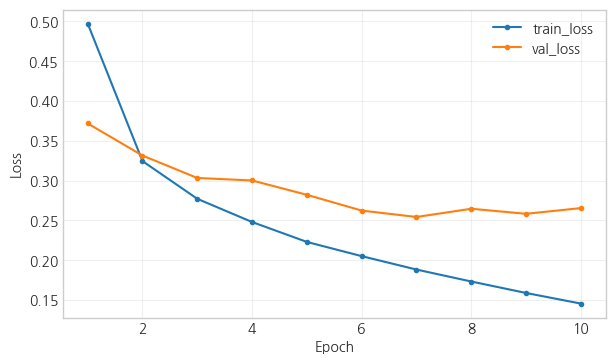

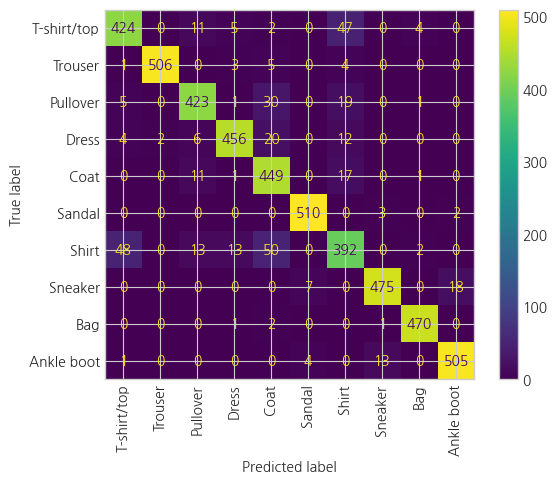

              precision    recall  f1-score   support

           0       0.88      0.86      0.87       493
           1       1.00      0.97      0.99       519
           2       0.91      0.88      0.90       479
           3       0.95      0.91      0.93       500
           4       0.80      0.94      0.87       479
           5       0.98      0.99      0.98       515
           6       0.80      0.76      0.78       518
           7       0.97      0.95      0.96       500
           8       0.98      0.99      0.99       474
           9       0.96      0.97      0.96       523

    accuracy                           0.92      5000
   macro avg       0.92      0.92      0.92      5000
weighted avg       0.92      0.92      0.92      5000



In [43]:
batch_size = 64
train_dataloader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

X_val, X_test = test_dataset.data[:5000], test_dataset.data[5000:]
y_val, y_test = test_dataset.targets[:5000], test_dataset.targets[5000:]

# 모든 픽셀값 [0,1] 범위로 변환
X_val = X_val / 255
X_test = X_test / 255

X_val = X_val.view(5000, 1, 28, 28)     # [1 * 28 * 28 이미지 5000장] 구조로 변환
X_test = X_test.view(5000, 1, 28, 28)

n_class = 10

# 모델 구조 설계
model1 = nn.Sequential(
    nn.Conv2d(1,32, kernel_size=3, padding=1),
    nn.ReLU(),
    nn.MaxPool2d(kernel_size=2, stride=2, padding=0),
    nn.Conv2d(32,64, kernel_size=3, padding=1),
    nn.ReLU(),
    nn.MaxPool2d(kernel_size=2, stride=2, padding=0),
    nn.Flatten(),
    nn.Linear(64*7*7, 64),
    nn.ReLU(),
    nn.Linear(64, n_class)
).to(device)

loss_fn = nn.CrossEntropyLoss()
optimizer = Adam(model1.parameters(), lr=0.001)

epochs = 10
tr_loss_list, val_loss_list = [], []

for t in range(epochs):
    tr_loss = train(train_dataloader, model1, loss_fn, optimizer, device)
    val_loss, _ = evaluate(X_val, y_val, model1, loss_fn, device)

    # 리스트에 loss 추가 --> learning curve 그리기 위해.
    tr_loss_list.append(tr_loss)
    val_loss_list.append(val_loss)

    print(f"Epoch {t+1}, train loss : {tr_loss:4f}, val loss : {val_loss:4f}")

dl_learning_curve(tr_loss_list, val_loss_list)

_, pred = evaluate(X_test, y_test, model1, loss_fn, device)
pred_prob = nn.functional.softmax(pred, dim=1)
pred_class = np.argmax(pred_prob.cpu().numpy(), axis=1)
cm = confusion_matrix(y_test.numpy(), pred_class)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=train_dataset.classes)
disp.plot()
plt.xticks(rotation=90)
plt.show()
print(classification_report(y_test.numpy(), pred_class))